In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re


<h3>Kiểm tra cấu trúc tổng quan</h3>

In [2]:
ankhang_df = pd.read_csv(r'D:\OU\KhoaLuanTotNghiep\DrugRecommandation\crawlData_AnKhang\ankhang_medicines_data_full.csv', encoding='utf-8-sig')
print(f"Số dòng: {ankhang_df.shape[0]}, Số cột: {ankhang_df.shape[1]}")
ankhang_df.info()
ankhang_df.head()

Số dòng: 2193, Số cột: 20
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2193 entries, 0 to 2192
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ten_thuoc            2139 non-null   object
 1   gia                  538 non-null    object
 2   hinh_anh             2102 non-null   object
 3   cong_dung_tom_tat    2139 non-null   object
 4   thanh_phan_chinh     2050 non-null   object
 5   doi_tuong            1817 non-null   object
 6   thuong_hieu          2137 non-null   object
 7   noi_san_xuat         2139 non-null   object
 8   dang_bao_che         2138 non-null   object
 9   han_dung             2119 non-null   object
 10  thanh_phan_chi_tiet  2131 non-null   object
 11  cong_dung_chi_tiet   2102 non-null   object
 12  cach_dung            2117 non-null   object
 13  chong_chi_dinh       2099 non-null   object
 14  tac_dung_phu         2042 non-null   object
 15  luu_y                925 non-

,ten_thuoc,gia,hinh_anh,cong_dung_tom_tat,thanh_phan_chinh,doi_tuong,thuong_hieu,noi_san_xuat,dang_bao_che,han_dung,thanh_phan_chi_tiet,cong_dung_chi_tiet,cach_dung,chong_chi_dinh,tac_dung_phu,luu_y,url,category,drug_type,error
0,"Timi Roitin trị viêm dây thần kinh, thoái hóa ...",528.000₫,https://cdn.tgdd.vn/Products/Images/10053/1304...,"Bổ sung vitamin nhóm B, điều trị viêm dây thần...","Chondroitin, Vitamin B5, Fursultiamine, Vitami...",Người lớn,Phil Inter Pharma,Việt Nam,Viên nang mềm,36 tháng kể từ ngày sản xuất,"Hoạt chất: Chondroitin sulfate natri 90mg, Nic...",- Bổ sung các vitamin nhóm B trong các trường ...,Người lớn: Uống 1 viên/ngày.\n- Quá liều\nDùng...,- Quá mẫn với bất cứ thành phần nào của thuốc....,TIMIROITIN thường được dung nạp tốt khi dùng ở...,- Thận trọng khi sử dụng\n- Khi sử dụng nicoti...,https://www.nhathuocankhang.com/thuoc-bo-va-vi...,Thuốc bổ và vitamin,Không kê đơn,NaN
1,B Complex C bổ sung vitamin nhóm B và vitamin ...,800₫,https://cdn.tgdd.vn/Products/Images/10053/1295...,Dự phòng & bổ sung khi thiếu hụt các vitamin n...,"Vitamin PP, Vitamin C, Vitamin B6, Vitamin B2,...",NaN,Vidipha,Việt Nam,Viên nang cứng,24 tháng kể từ ngày sản xuất,"Hoạt chất: Vitamin B1 15mg, Vitamin B2 10mg, V...",B Complex C dự phòng và bổ sung thiếu hụt các ...,Liều lượng: Trung bình: 1 - 2 viên/ngày.\nCách...,Dị ứng với một trong các thành phần của thuốc....,Dùng liều cao nước tiểu sẽ có màu vàng nhạt (d...,- Thận trọng khi sử dụng\nKhi sử dụng nicotina...,https://www.nhathuocankhang.com/thuoc-bo-va-vi...,Thuốc bổ và vitamin,Không kê đơn,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.nhathuocankhang.com/thuoc-bo-va-vi...,NaN,NaN,Message: no such element: Unable to locate ele...
3,Vitamin PP 50 Pharmedic ngăn ngừa thiếu nicoti...,12.000₫,https://cdn.tgdd.vn/Products/Images/10053/1533...,Bổ sung vào khẩu phần ăn để ngăn ngừa thiếu hụ...,Vitamin PP,Người lớn và trẻ em trên 5 tuổi,Pharmedic,Việt Nam,Viên nén,NaN,Nicotinamid 50mg.\nTá dược 1 viên.,Vitamin PP 50 giúp bổ sung vào khẩu phần ăn để...,"Người lớn: mỗi lần 1 - 2 viên, ngày 3 lần.\nTr...","- Dị ứng với nicotinamid.\n- Bệnh gan nặng, lo...",NaN,- Thận trọng khi sử dụng\nNgười có tiền sử loé...,https://www.nhathuocankhang.com/thuoc-bo-va-vi...,Thuốc bổ và vitamin,Không kê đơn,NaN
4,"Agi-Calci bổ sung canxi, trị loãng xương (20 v...",150.000₫,https://cdn.tgdd.vn/Products/Images/10053/2463...,Bổ sung calci khi thiếu hay tăng nhu cầu calci...,"Calci cacbonat, Vitamin D3",NaN,Agimexpharm,Việt Nam,Viên nén bao phim,24 tháng kể từ ngày sản xuất,Mỗi viên nén bao phim chứa:\nHoạt chất: Calci ...,- Agi-Calci bổ sung calci trong các trường hợp...,Uống thuốc buổi sáng hoặc buổi trưa theo liều ...,"- Tăng calci huyết, calci niệu, sỏi calci, suy...",- Dùng thuốc chứa muối calci qua đường uống có...,- Thận trọng khi sử dụng\nThận trọng khi sử dụ...,https://www.nhathuocankhang.com/thuoc-bo-va-vi...,Thuốc bổ và vitamin,Không kê đơn,NaN


<h3>Kiểm tra giá trị thiếu</h3>

In [3]:
# Kiểm tra giá trị thiếu ở mỗi cột
missing_values = ankhang_df.isnull().sum()
print("Số lượng giá trị thiếu ở mỗi cột:")
print(missing_values)

# Kiểm tra giá trị thiếu tính theo phần trăm
missing_percentage = round((ankhang_df.isnull().sum() / len(ankhang_df)) * 100, 2)
print("\nPhần trăm giá trị thiếu ở mỗi cột:") 
print(missing_percentage)


Số lượng giá trị thiếu ở mỗi cột:
ten_thuoc                54
gia                    1655
hinh_anh                 91
cong_dung_tom_tat        54
thanh_phan_chinh        143
doi_tuong               376
thuong_hieu              56
noi_san_xuat             54
dang_bao_che             55
han_dung                 74
thanh_phan_chi_tiet      62
cong_dung_chi_tiet       91
cach_dung                76
chong_chi_dinh           94
tac_dung_phu            151
luu_y                  1268
url                       0
category                120
drug_type               120
error                  2139
dtype: int64

Phần trăm giá trị thiếu ở mỗi cột:
ten_thuoc               2.46
gia                    75.47
hinh_anh                4.15
cong_dung_tom_tat       2.46
thanh_phan_chinh        6.52
doi_tuong              17.15
thuong_hieu             2.55
noi_san_xuat            2.46
dang_bao_che            2.51
han_dung                3.37
thanh_phan_chi_tiet     2.83
cong_dung_chi_tiet      4.15
cach_dung

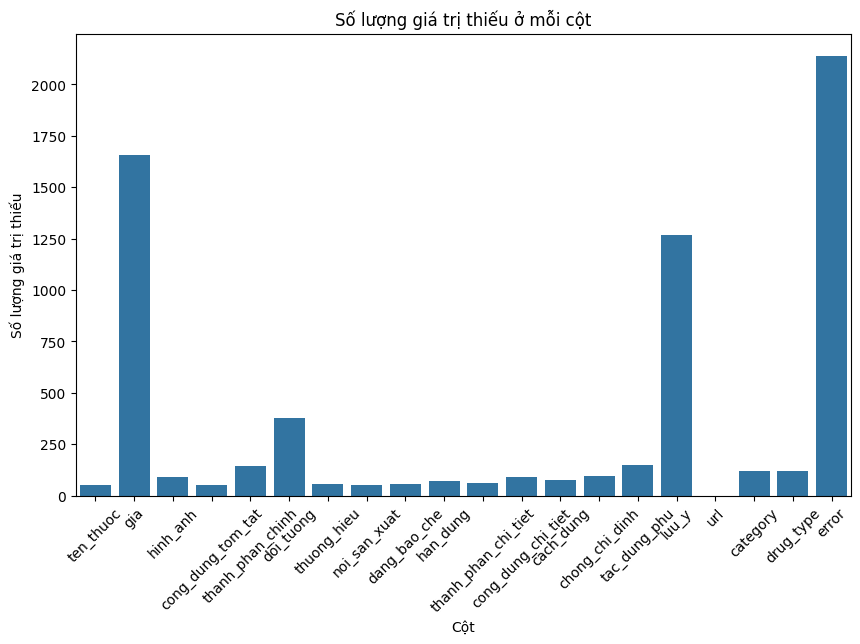

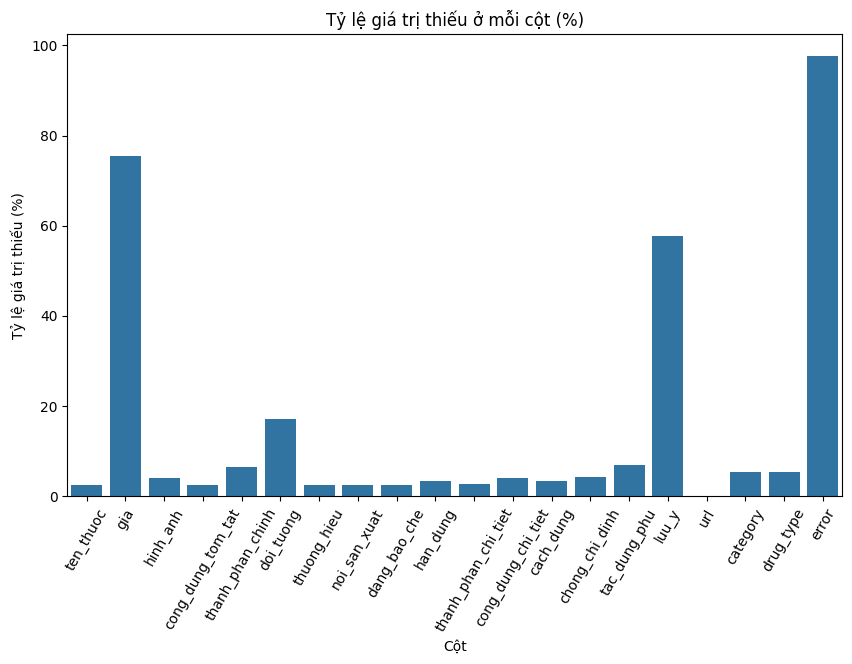

In [14]:
# Vẽ biểu đồ giá trị thiếu theo cột (Số lượng)
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values.index, y=missing_values.values)
plt.title('Số lượng giá trị thiếu ở mỗi cột')
plt.xlabel('Cột')
plt.ylabel('Số lượng giá trị thiếu')
plt.xticks(rotation=45)
plt.show()


# Vẽ biểu đồ giá trị thiếu theo cột (%)
missing_percent = (missing_values / len(ankhang_df)) * 100
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_percent.index, y=missing_percent.values)
plt.title('Tỷ lệ giá trị thiếu ở mỗi cột (%)')
plt.xlabel('Cột')
plt.ylabel('Tỷ lệ giá trị thiếu (%)')
plt.xticks(rotation=60)
plt.show()

In [5]:
# Các url đang có giá trị NaN
nan_urls = ankhang_df[ankhang_df['url'].isnull()]
print("Các dòng có giá trị NaN ở cột 'url':")
print(nan_urls)

Các dòng có giá trị NaN ở cột 'url':
Empty DataFrame
Columns: [ten_thuoc, gia, hinh_anh, cong_dung_tom_tat, thanh_phan_chinh, doi_tuong, thuong_hieu, noi_san_xuat, dang_bao_che, han_dung, thanh_phan_chi_tiet, cong_dung_chi_tiet, cach_dung, chong_chi_dinh, tac_dung_phu, luu_y, url, category, drug_type, error]
Index: []


In [6]:
ankhang_df = ankhang_df.copy()
# Kiểm tra số lượng dòng bị error (NaN)
error_counts = ankhang_df[ankhang_df['ten_thuoc'].isnull() | ankhang_df['ten_thuoc'].isna()]
print(f"Số dòng bị lỗi: {error_counts.shape[0]}")
print(error_counts)

Số dòng bị lỗi: 54
     ten_thuoc  gia hinh_anh cong_dung_tom_tat thanh_phan_chinh doi_tuong  \
2          NaN  NaN      NaN               NaN              NaN       NaN   
13         NaN  NaN      NaN               NaN              NaN       NaN   
83         NaN  NaN      NaN               NaN              NaN       NaN   
106        NaN  NaN      NaN               NaN              NaN       NaN   
124        NaN  NaN      NaN               NaN              NaN       NaN   
136        NaN  NaN      NaN               NaN              NaN       NaN   
137        NaN  NaN      NaN               NaN              NaN       NaN   
334        NaN  NaN      NaN               NaN              NaN       NaN   
335        NaN  NaN      NaN               NaN              NaN       NaN   
477        NaN  NaN      NaN               NaN              NaN       NaN   
499        NaN  NaN      NaN               NaN              NaN       NaN   
533        NaN  NaN      NaN               NaN           

<h3>Kiểm tra giá trị trùng lặp</h3>

In [7]:
# Kiểm tra giá trị trùng lặp hoàn toàn
duplicate_rows = ankhang_df[ankhang_df.duplicated()]
print("Số lượng các dòng trùng lặp:", duplicate_rows.shape[0])
print("Các dòng trùng lặp:")
print(duplicate_rows)

Số lượng các dòng trùng lặp: 159
Các dòng trùng lặp:
                                              ten_thuoc       gia  \
1969  Timi Roitin trị viêm dây thần kinh, thoái hóa ...  528.000₫   
1970  B Complex C bổ sung vitamin nhóm B và vitamin ...      800₫   
1971                                                NaN       NaN   
1972  Vitamin PP 50 Pharmedic ngăn ngừa thiếu nicoti...   12.000₫   
1973  Agi-Calci bổ sung canxi, trị loãng xương (20 v...  150.000₫   
...                                                 ...       ...   
2188  Vitamin A-D HDpharma điều trị tình trạng thiếu...       NaN   
2189  Savprocal D hỗ trợ điều trị đặc hiệu bệnh loãn...       NaN   
2190  Savprocal D hỗ trợ điều trị đặc hiệu bệnh loãn...       NaN   
2191  Furagon phòng và trị bệnh do chuyển hoá protei...       NaN   
2192  Furagon phòng và trị bệnh do chuyển hoá protei...       NaN   

                                               hinh_anh  \
1969  https://cdn.tgdd.vn/Products/Images/10053/1304...   


In [8]:
# kiểm tra giá trị trung lặp theo URL
pd.set_option('display.max_colwidth', None)
duplicate_urls = ankhang_df[ankhang_df.duplicated(subset=['url'])]
print("Số lượng các dòng có URL trùng lặp:", duplicate_urls.shape[0])
print("Các dòng có URL trùng lặp:")
print(duplicate_urls['url'])


Số lượng các dòng có URL trùng lặp: 224
Các dòng có URL trùng lặp:
1969    https://www.nhathuocankhang.com/thuoc-bo-va-vitamin/thuoc-bo-sung-vitamin-b-timi-roitin-120-vien?sku=1193668000314
1970                                     https://www.nhathuocankhang.com/thuoc-bo-va-vitamin/b-complex-c?sku=1193668000204
1971                      https://www.nhathuocankhang.com/thuoc-bo-va-vitamin/cezinco-110mg-5ml-h-30-ong?sku=1193668000849
1972                                   https://www.nhathuocankhang.com/thuoc-bo-va-vitamin/vitamin-pp-50?sku=1193687000032
1973                                https://www.nhathuocankhang.com/thuoc-bo-va-vitamin/agi-calci-h-200v?sku=1193668000576
                                                               ...                                                        
2188                https://www.nhathuocankhang.com/thuoc-bo-va-vitamin/vitamin-a-d-5000ui-400ui-hd-100v?sku=1193668000844
2189                    https://www.nhathuocankhang.com/thuoc-bo-va-vita

In [9]:
pd.reset_option('display.max_colwidth')

In [10]:
# Kiểm tra các giá trị trùng lặp
duplicate_rows = ankhang_df[ankhang_df.duplicated()]
print("Số lượng các dòng trùng lặp:", duplicate_rows.shape[0])
print("Các dòng trùng lặp:")
print(duplicate_rows)


Số lượng các dòng trùng lặp: 159
Các dòng trùng lặp:
                                              ten_thuoc       gia  \
1969  Timi Roitin trị viêm dây thần kinh, thoái hóa ...  528.000₫   
1970  B Complex C bổ sung vitamin nhóm B và vitamin ...      800₫   
1971                                                NaN       NaN   
1972  Vitamin PP 50 Pharmedic ngăn ngừa thiếu nicoti...   12.000₫   
1973  Agi-Calci bổ sung canxi, trị loãng xương (20 v...  150.000₫   
...                                                 ...       ...   
2188  Vitamin A-D HDpharma điều trị tình trạng thiếu...       NaN   
2189  Savprocal D hỗ trợ điều trị đặc hiệu bệnh loãn...       NaN   
2190  Savprocal D hỗ trợ điều trị đặc hiệu bệnh loãn...       NaN   
2191  Furagon phòng và trị bệnh do chuyển hoá protei...       NaN   
2192  Furagon phòng và trị bệnh do chuyển hoá protei...       NaN   

                                               hinh_anh  \
1969  https://cdn.tgdd.vn/Products/Images/10053/1304...   


<h3>Kiểm tra phân bố nhãn</h3>

Số lượng bệnh theo category:
category
Thuốc bổ và vitamin                            434
Kháng sinh, kháng nấm                          257
Giảm đau, hạ sốt, kháng viêm                   215
Thần kinh, não bộ                              210
Tim mạch, tiểu đường, mỡ máu                   201
Da liễu, dị ứng                                200
Tiêu hóa, gan mật                              189
Hô hấp                                         147
Tiết niệu, sinh dục                            104
Cơ xương khớp, gút                              61
Mắt, tai mũi họng                               21
Dầu, Cao Xoa, Miếng Dán                         17
Thuốc điều trị ung thư, miễn dịch               10
Thuốc làm đẹp, giảm cân                          5
Thuốc giải độc, khử độc - hỗ trợ cai nghiện      2
Name: count, dtype: int64


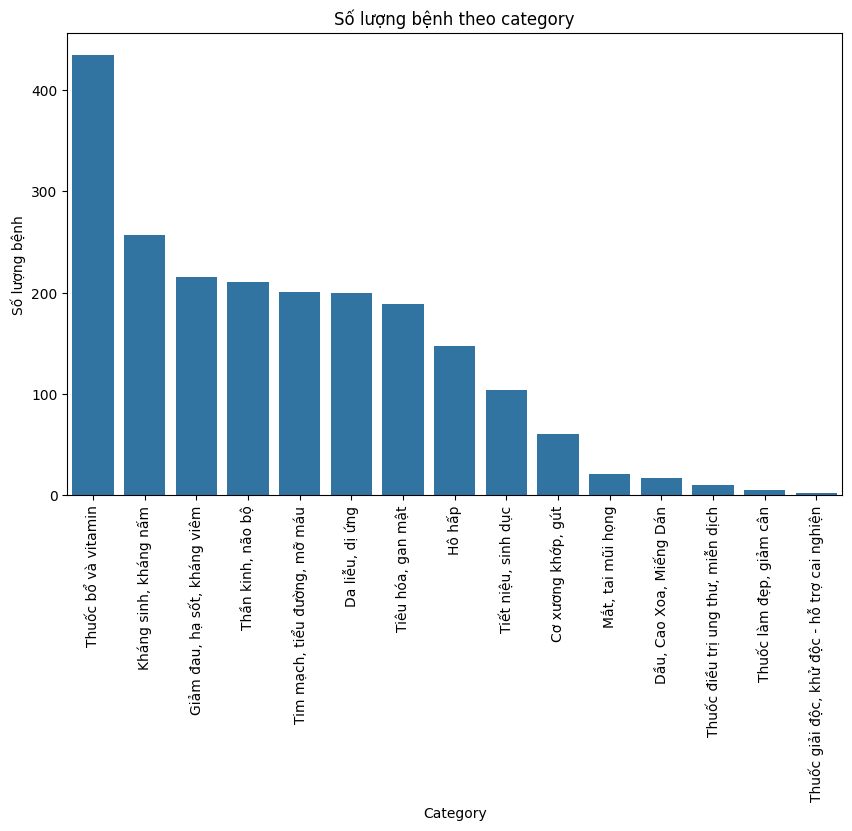

In [13]:
# Kiểm tra số lượng bệnh theo category
category_counts = ankhang_df['category'].value_counts()
print("Số lượng bệnh theo category:")
print(category_counts)


# Vẽ biểu đồ số lượng bệnh theo category
plt.figure(figsize=(10, 6))
sns.barplot(x=category_counts.index, y=category_counts.values)
plt.title('Số lượng bệnh theo category')
plt.xlabel('Category')
plt.ylabel('Số lượng bệnh')
plt.xticks(rotation=90)
plt.show()